In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [34]:
df=pd.read_csv("house_price_regression_dataset.csv")
df.head(4)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262382.852274
1,4272,3,3,2016,4.753014,1,6,985260.854490
2,3592,1,2,2016,3.634823,0,9,777977.390119
3,966,1,2,1977,2.730667,1,8,229698.918664


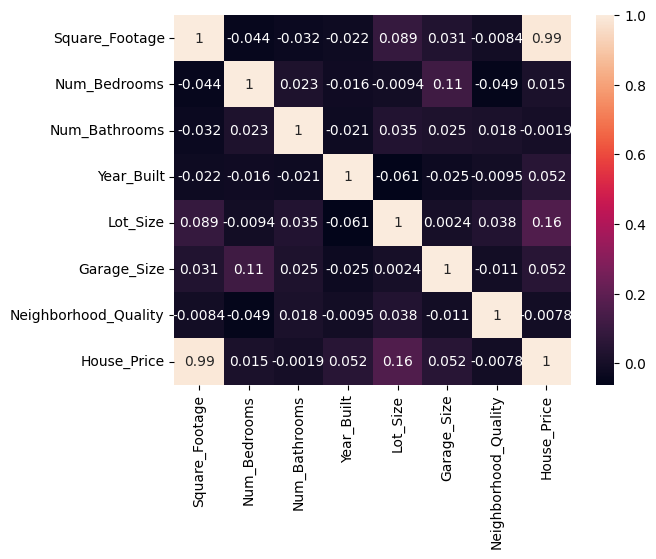

In [35]:
sns.heatmap(data=df.corr(),annot=True)
plt.show()

In [36]:
ms=MinMaxScaler()
ms.fit(df)
a=ms.transform(df)
df=pd.DataFrame(a,columns=df.columns)

In [37]:
x=df.iloc[:,:-1]
y=df["House_Price"]
x

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,0.190614,0.25,0.0,0.430556,0.020873,0.0,0.444444
1,0.838301,0.50,1.0,0.916667,0.947295,0.5,0.555556
2,0.687055,0.00,0.5,0.916667,0.697880,0.0,0.888889
3,0.102980,0.00,0.5,0.375000,0.496205,0.5,0.777778
4,0.983763,0.25,0.0,0.597222,0.935263,0.0,0.777778
...,...,...,...,...,...,...,...
995,0.613434,0.75,0.0,0.388889,0.370056,1.0,1.000000
996,0.595196,0.00,0.5,0.680556,0.551178,0.5,1.000000
997,0.467749,0.75,0.5,0.166667,0.791616,0.0,0.111111
998,0.938612,1.00,0.5,0.000000,0.317820,0.0,0.666667


In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=48)

LINEAR REGRESSION

In [39]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [40]:
lr.score(x_test,y_test)

0.9985725868986024

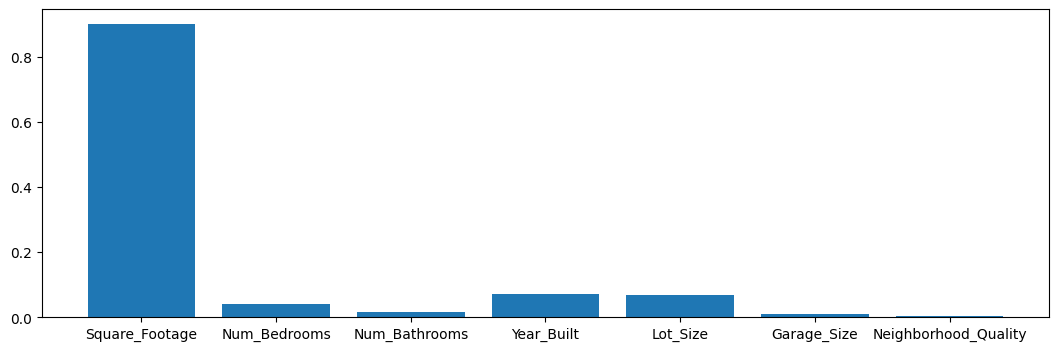

In [41]:
plt.figure(figsize=[13,4])
plt.bar(x.columns,lr.coef_)
plt.show()

RIDGE

In [72]:
ri=Ridge(alpha=0.01)
ri.fit(x_train,y_train)

Ridge(alpha=0.01)

In [73]:
ri.score(x_test,y_test)

0.9985732354879658

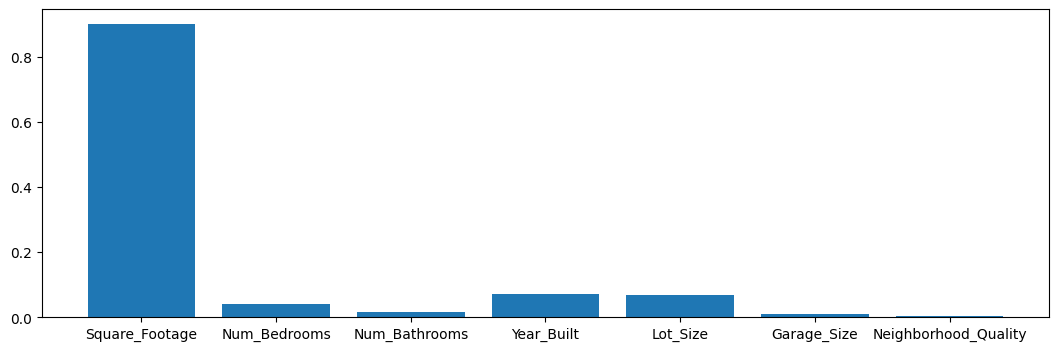

In [74]:
plt.figure(figsize=[13,4])
plt.bar(x.columns,ri.coef_)
plt.show()

LASSO

In [69]:
ls=Lasso(alpha=0.005)
ls.fit(x_train,y_train)

Lasso(alpha=0.005)

In [70]:
ls.score(x_test,y_test)

0.9835369407392077

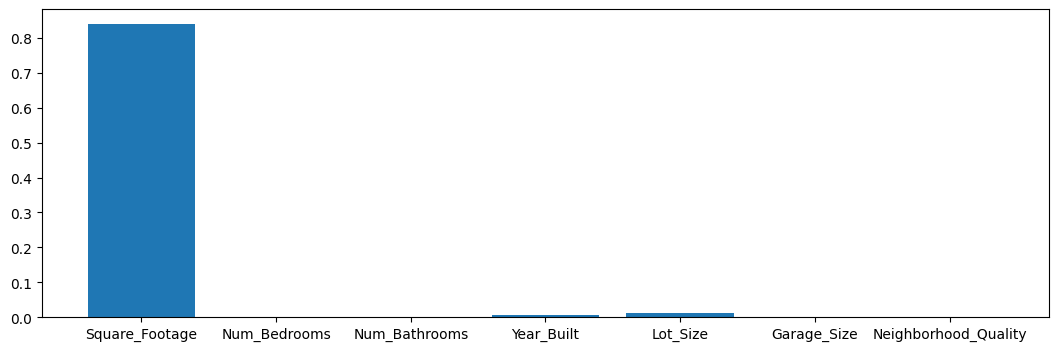

In [71]:
plt.figure(figsize=[13,4])
plt.bar(x.columns,ls.coef_)
plt.show()

ERROR CALCULATION

In [80]:
ls_m=np.sqrt(mean_squared_error(y_test, ls.predict(x_test)))
ri_m=np.sqrt(mean_squared_error(y_test, ri.predict(x_test)))
lr_m=np.sqrt(mean_squared_error(y_test, lr.predict(x_test)))
print(ls_m,ri_m,lr_m)

0.03303125588893337 0.009724022721521498 0.009726232680157633


In [79]:
coef_table=pd.DataFrame({"column":df.columns[:-1],"linear_coef":lr.coef_,"ridge_coeff":ri.coef_,"lasso_coef":ls.coef_})
coef_table

,column,linear_coef,ridge_coeff,lasso_coef
0,Square_Footage,0.901622,0.901463,0.840906
1,Num_Bedrooms,0.040625,0.040617,0.000000
2,Num_Bathrooms,0.015822,0.015818,0.000000
3,Year_Built,0.071743,0.071732,0.007116
4,Lot_Size,0.066962,0.066967,0.012233
5,Garage_Size,0.010985,0.010987,0.000000
6,Neighborhood_Quality,0.002363,0.002363,0.000000
